# Monty Hall

In [30]:
import numpy as np
import pylab as plt


Caso  10
Percentuali:
 - Switcher:  90.0 %
 - Conservative  10.0 %
 - New comer  70.0 %

Caso  100
Percentuali:
 - Switcher:  64.0 %
 - Conservative  36.0 %
 - New comer  50.0 %

Caso  1000
Percentuali:
 - Switcher:  65.7 %
 - Conservative  34.300000000000004 %
 - New comer  48.9 %

Caso  10000
Percentuali:
 - Switcher:  66.35 %
 - Conservative  33.650000000000006 %
 - New comer  50.41 %

Caso  100000
Percentuali:
 - Switcher:  66.769 %
 - Conservative  33.231 %
 - New comer  49.97 %
[90.0, 64.0, 65.7, 66.35, 66.769] [10.0, 36.0, 34.300000000000004, 33.650000000000006, 33.231] [70.0, 50.0, 48.9, 50.41, 49.97]


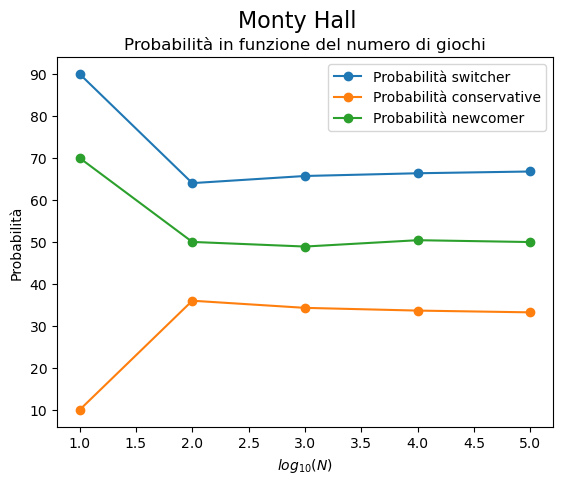

In [80]:
N = [10,100,1000,10000,100000]
arr_switch = []
arr_cons = []
arr_new = []

for n in N:
    
    v_switcher = 0
    v_conservative = 0
    v_newcomer = 0
    print('\nCaso ',n)

    for i in range(n):
        
        porte = np.array([0,0,1])
        scelta = np.random.randint(0, 3)
        #print ('Porta scelta: ',scelta)
    
        possibili = np.where((porte == 0) & (np.arange(3) != scelta))[0]
        elimina = np.random.choice(possibili)
        
        new = [j for j in range(3) if j not in [scelta, elimina]][0]
    
        if porte[new] == 1:
            v_switcher += 1
    
        scelta_new = np.random.choice([scelta, new])
        if porte[scelta_new] == 1:
            v_newcomer += 1
    
        if porte[scelta] == 1:
            v_conservative +=1
             
    #print ('Vittorie switcher: ',v_switcher)
    #print ('Vittorie newcomer: ',v_newcomer)
    #print ('Vittorie conservative: ',v_conservative)
    
    print('Percentuali:\n - Switcher: ',v_switcher/n*100,'%\n - Conservative ',v_conservative/n*100,'%\n - New comer ',v_newcomer/n*100,'%')

    arr_switch.append(v_switcher/n*100)
    arr_cons.append(v_conservative/n*100)
    arr_new.append(v_newcomer/n*100)

print(arr_switch, arr_cons, arr_new)

plt.plot(np.log10(N), arr_switch, marker='o', label='Probabilità switcher')
plt.plot(np.log10(N), arr_cons, marker='o', label='Probabilità conservative')
plt.plot(np.log10(N), arr_new, marker='o', label='Probabilità newcomer')

plt.suptitle('Monty Hall', fontsize = 16)
plt.title('Probabilità in funzione del numero di giochi')

plt.xlabel(r'$log_{10}(N)$')
plt.ylabel('Probabilità')
plt.legend(loc='upper right')

# N porte


Ciclo numero  1
Porte totali: 10, porte aperte: 1, tentativi: 1000
Percentuali:
Switcher: 9.8 %
Conservative: 9.7 %
Newcomer: 9.6 %

Ciclo numero  2
Porte totali: 10, porte aperte: 2, tentativi: 1000
Percentuali:
Switcher: 12.2 %
Conservative: 10.4 %
Newcomer: 10.7 %

Ciclo numero  3
Porte totali: 10, porte aperte: 3, tentativi: 1000
Percentuali:
Switcher: 15.8 %
Conservative: 10.5 %
Newcomer: 12.6 %

Ciclo numero  4
Porte totali: 10, porte aperte: 4, tentativi: 1000
Percentuali:
Switcher: 17.1 %
Conservative: 10.4 %
Newcomer: 14.5 %

Ciclo numero  5
Porte totali: 10, porte aperte: 5, tentativi: 1000
Percentuali:
Switcher: 22.5 %
Conservative: 11.1 %
Newcomer: 15.4 %

Ciclo numero  6
Porte totali: 10, porte aperte: 6, tentativi: 1000
Percentuali:
Switcher: 29.5 %
Conservative: 12.2 %
Newcomer: 22.7 %

Ciclo numero  7
Porte totali: 10, porte aperte: 7, tentativi: 1000
Percentuali:
Switcher: 45.7 %
Conservative: 10.4 %
Newcomer: 28.5 %

Ciclo numero  8
Porte totali: 10, porte aperte: 8,

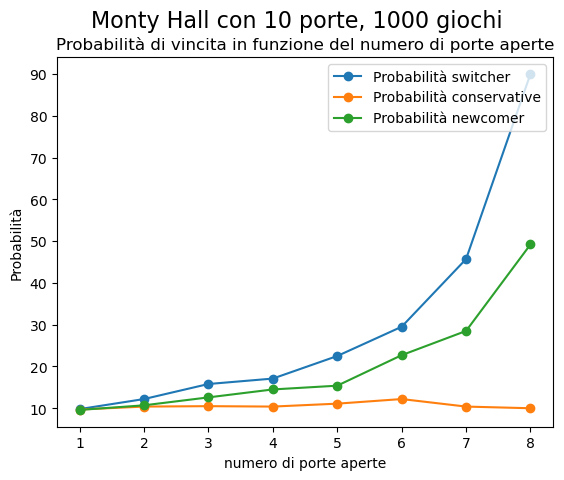

In [83]:
import numpy as np

N = 1000
arr_switch = []
arr_cons = []
arr_new = []



n_porte = 10
aperte = np.arange(1,n_porte-1)

for p in aperte:

    v_switcher = 0
    v_conservative = 0
    v_newcomer = 0
    
    for i in range(N):
    
        porte_aperte = []
        possibili = []
    
        porte = np.concatenate((np.zeros(n_porte-1), [1]))
        np.random.shuffle(porte)
        scelta = np.random.randint(0, n_porte)
    
        
        for x in range(p):
            #qui seleziono solo le porte che il presentatore può aprire, 
            #cioè quelle che contengono una capira, doverse dalla scelte e diverse da quelle già aperte
            
            possibili = np.where((porte == 0) & (np.arange(n_porte) != scelta) & (~np.isin(np.arange(n_porte), porte_aperte)))[0]
            elimina = np.random.choice(possibili)
            porte_aperte.append(elimina)
    
        chiuse = []
    
        for j in range(n_porte):
            if j not in porte_aperte:
                chiuse.append(j)
    
        rimaste_chiuse = []
        for j in chiuse:
            if j != scelta:
                rimaste_chiuse.append(j)
    
        new = np.random.choice(rimaste_chiuse)
    
        #switch
        if porte[new] == 1:
            v_switcher += 1
    
        # newcomer
        scelta_new = np.random.choice([scelta, new])
        if porte[scelta_new] == 1:
            v_newcomer += 1
    
        # conservative
        if porte[scelta] == 1:
            v_conservative += 1

    arr_switch.append(v_switcher/N*100)
    arr_cons.append(v_conservative/N*100)
    arr_new.append(v_newcomer/N*100)

    
    
    print('\nCiclo numero ',p)


    print(f'Porte totali: {n_porte}, porte aperte: {p}, tentativi: {N}')
    
    print("Percentuali:")
    print("Switcher:", 100*v_switcher/N, "%")
    print("Conservative:", 100*v_conservative/N, "%")
    print("Newcomer:", 100*v_newcomer/N, "%")

#print(arr_switch, arr_cons, arr_new)


plt.plot(aperte, arr_switch, marker='o', label='Probabilità switcher')
plt.plot(aperte, arr_cons, marker='o', label='Probabilità conservative')
plt.plot(aperte, arr_new, marker='o', label='Probabilità newcomer')

plt.suptitle(f'Monty Hall con {n_porte} porte, {N} giochi', fontsize = 16)
plt.title('Probabilità di vincita in funzione del numero di porte aperte')
plt.xlabel('numero di porte aperte')
plt.ylabel('Probabilità')
plt.legend(loc='upper right')